# Funafuti Elevation-Threshold Exposure Analysis

This notebook combines the Funafuti ASTER DEM and WorldPop raster to estimate
land and population exposure at five elevation thresholds: 0.0, 0.5, 1.0,
1.5 and 2.0 m.

The thresholds are illustrative. They are not assigned to forecast years and
are not derived from the observed SPC sea-level anomaly series.

Outputs are written to `output/sea_level_scenarios.json` and used by the
interactive site.

## 1. Setup

In [1]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Portable project root: works when Jupyter is launched from the repo root
# or from the notebooks/ directory. No machine-specific absolute paths.
PROJECT_ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEM_PATH = PROJECT_ROOT / "data" / "raw" / "tuvalu_dem_funafuti_admin.tif"
POP_PATH = PROJECT_ROOT / "data" / "raw" / "tuvalu_pop_funafuti_admin.tif"
OUTPUT_JSON = OUTPUT_DIR / "sea_level_scenarios.json"

print("DEM path:", DEM_PATH, "exists:", DEM_PATH.exists())
print("Population path:", POP_PATH, "exists:", POP_PATH.exists())

# Illustrative relative sea-level increments (metres).
# These are elevation-threshold scenarios, not year-specific forecasts.
# The observed 1993–2023 SPC sea-level anomaly series is independent from
# these thresholds and is not used to derive them.
SCENARIOS = [
    {"label": "Baseline (0.0m)", "rise_m": 0.0},
    {"label": "+0.5m", "rise_m": 0.5},
    {"label": "+1.0m", "rise_m": 1.0},
    {"label": "+1.5m", "rise_m": 1.5},
    {"label": "+2.0m", "rise_m": 2.0},
]


DEM path: ..\data\raw\tuvalu_dem_funafuti_admin.tif exists: True
Population path: ..\data\raw\tuvalu_pop_funafuti_admin.tif exists: True


## 2. DEM and pixel area

Area calculations use the projected DEM grid. The analysis stops if the DEM
is not in a projected CRS because pixel area in degrees is not suitable for
this calculation.

In [2]:
with rasterio.open(DEM_PATH) as dem_src:
    dem = dem_src.read(1)
    dem_nodata = dem_src.nodata
    dem_shape = dem.shape
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs

    if dem_crs is None or not dem_crs.is_projected:
        raise ValueError(
            "The Funafuti DEM must use a projected CRS before area is calculated."
        )

    pixel_area_m2 = abs(dem_transform.a * dem_transform.e)

print(f"DEM shape: {dem_shape}, CRS: {dem_crs}, pixel area: {pixel_area_m2:.2f} m2")

DEM shape: (3554, 3939), CRS: EPSG:3832, pixel area: 949.82 m2


## 3. Population alignment

WorldPop and ASTER have different native grids. WorldPop is reprojected to the
DEM grid with nearest-neighbour resampling. Source NoData values are removed,
then the aligned raster is rescaled to preserve the native clipped WorldPop
total.

In [3]:
with rasterio.open(POP_PATH) as pop_src:
    population_native = pop_src.read(1)
    pop_nodata = pop_src.nodata
    pop_native_valid = population_native[population_native != pop_nodata] if pop_nodata is not None else population_native
    population_true_total = float(pop_native_valid[pop_native_valid > 0].sum())
    print(f"Native-resolution population total (pre-resampling): {population_true_total:,.0f}")

    if pop_src.shape != dem_shape or pop_src.transform != dem_transform:
        print(f"Population grid ({pop_src.shape}) does not match DEM grid ({dem_shape}) "
              f"-- resampling population onto the DEM's grid.")
        population = np.zeros(dem_shape, dtype=np.float64)
        reproject(
            source=population_native,
            destination=population,
            src_transform=pop_src.transform,
            src_crs=pop_src.crs,
            src_nodata=pop_nodata,
            dst_transform=dem_transform,
            dst_crs=dem_crs,
            dst_nodata=0,
            resampling=Resampling.nearest,
        )
        if pop_nodata is not None:
            population[population == pop_nodata] = 0

        # Nearest-neighbour resampling onto a finer grid does not by itself
        # preserve the total population count (each coarse pixel's value
        # gets duplicated across multiple finer pixels), so rescale the
        # whole array to force the resampled total to match the true total
        # from the native (coarser) raster.
        resampled_total = float(population[population > 0].sum())
        if resampled_total > 0:
            population *= population_true_total / resampled_total
    else:
        population = population_native.astype(np.float64)
        if pop_nodata is not None:
            population[population == pop_nodata] = 0

print(f"Population total after resampling (should match native total): {population[population > 0].sum():,.0f}")

Native-resolution population total (pre-resampling): 6,320
Population grid ((1323, 1309)) does not match DEM grid ((3554, 3939)) -- resampling population onto the DEM's grid.


Population total after resampling (should match native total): 6,320


## 4. Baseline

In [4]:
baseline_land_mask = (dem > 0) & (dem != dem_nodata)
baseline_land_area_km2 = baseline_land_mask.sum() * pixel_area_m2 / 1e6

# Population values are modelled raster estimates and can be fractional after
# reprojection/rescaling. Keep the exact sum for percentage calculations, but
# use one rounded whole-person count for reporting/export consistency.
baseline_population = population[baseline_land_mask].sum()
baseline_population_count = int(round(float(baseline_population)))

print(
    f"Model baseline land area: {baseline_land_area_km2:.3f} km2 "
    "(DEM pixels > 0 m inside the Funafuti study-area clip; "
    "not Funafuti's official land-area statistic)"
)
print(
    f"Model baseline population: {baseline_population_count:,} "
    "(WorldPop modelled population overlapping those DEM-positive pixels)"
)
print(
    f"Native clipped WorldPop total: {population_true_total:,.0f} "
    "(study-area clip before DEM-positive masking)"
)
print(
    "Reference check: Funafuti's 2017 resident population = 6,320. "
    "The WorldPop value is a modelled estimate, so this comparison is a sanity check, "
    "not a claim that the two datasets are equivalent."
)

Model baseline land area: 3.502 km2 (DEM pixels > 0 m inside the Funafuti study-area clip; not Funafuti's official land-area statistic)
Model baseline population: 5,905 (WorldPop modelled population overlapping those DEM-positive pixels)
Native clipped WorldPop total: 6,320 (study-area clip before DEM-positive masking)
Reference check: Funafuti's 2017 resident population = 6,320. The WorldPop value is a modelled estimate, so this comparison is a sanity check, not a claim that the two datasets are equivalent.


## 5. Elevation thresholds

For each threshold, a baseline land pixel is classed as exposed when its DEM
elevation is at or below the threshold.

This is a screening-level elevation analysis. It does not model tides, waves,
storm surge, groundwater, erosion, drainage, coastal defences, hydrodynamic
connectivity or shoreline change.

In [5]:
results = []
flood_masks = {}  # retained for the notebook visualisation below

for scenario in SCENARIOS:
    rise = scenario["rise_m"]
    flooded_mask = baseline_land_mask & (dem <= rise)
    remaining_land_mask = baseline_land_mask & (dem > rise)
    flood_masks[scenario["label"]] = flooded_mask

    flooded_area_km2 = flooded_mask.sum() * pixel_area_m2 / 1e6
    remaining_land_km2 = remaining_land_mask.sum() * pixel_area_m2 / 1e6

    # Exact modelled sums for percentages.
    population_exposed = population[flooded_mask].sum()

    # Report whole-person estimates consistently using rounding, not int()
    # truncation. Derive remaining from the rounded baseline so exposed +
    # remaining always equals the reported baseline count.
    population_exposed_count = int(round(float(population_exposed)))
    population_remaining_count = baseline_population_count - population_exposed_count

    results.append({
        "label": scenario["label"],
        "rise_m": rise,
        "flooded_area_km2": round(float(flooded_area_km2), 3),
        "remaining_land_km2": round(float(remaining_land_km2), 3),
        "land_loss_pct": round(float(flooded_area_km2 / baseline_land_area_km2 * 100), 1)
            if baseline_land_area_km2 > 0 else 0,
        "population_exposed": population_exposed_count,
        "population_remaining": population_remaining_count,
        "population_exposed_pct": round(float(population_exposed / baseline_population * 100), 1)
            if baseline_population > 0 else 0,
    })

for r in results:
    print(
        f"{r['label']:18s} | area at/below threshold {r['land_loss_pct']:5.1f}% | "
        f"population exposed {r['population_exposed']:6d} "
        f"({r['population_exposed_pct']:5.1f}%)"
    )


expected_labels = ["Baseline (0.0m)", "+0.5m", "+1.0m", "+1.5m", "+2.0m"]
assert [r["label"] for r in results] == expected_labels
assert results[0]["population_exposed"] == 0
assert results[0]["land_loss_pct"] == 0.0
assert all(
    results[i]["land_loss_pct"] <= results[i + 1]["land_loss_pct"]
    for i in range(len(results) - 1)
)
assert all(
    results[i]["population_exposed"] <= results[i + 1]["population_exposed"]
    for i in range(len(results) - 1)
)
assert all(
    r["population_exposed"] + r["population_remaining"] == baseline_population_count
    for r in results
)

Baseline (0.0m)    | area at/below threshold   0.0% | population exposed      0 (  0.0%)
+0.5m              | area at/below threshold   0.0% | population exposed      0 (  0.0%)
+1.0m              | area at/below threshold  15.5% | population exposed    201 (  3.4%)
+1.5m              | area at/below threshold  15.5% | population exposed    201 (  3.4%)
+2.0m              | area at/below threshold  27.7% | population exposed    532 (  9.0%)


## 6. Scenario summary

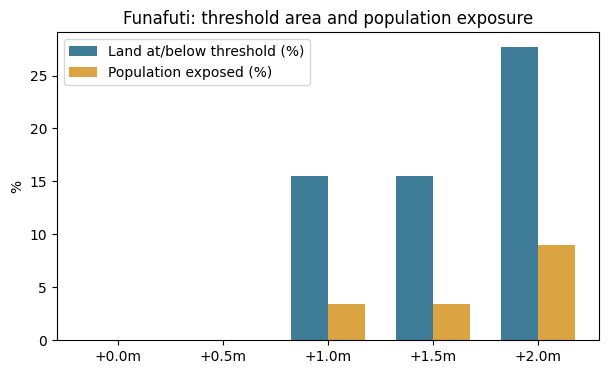

In [6]:
labels = [r["rise_m"] for r in results]
land_loss = [r["land_loss_pct"] for r in results]
pop_exposed_pct = [r["population_exposed_pct"] for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, land_loss, width, label="Land at/below threshold (%)", color="#3E7C97")
ax.bar(x + width/2, pop_exposed_pct, width, label="Population exposed (%)", color="#D9A441")
ax.set_xticks(x)
ax.set_xticklabels([f"+{r}m" for r in labels])
ax.set_ylabel("%")
ax.set_title("Funafuti: threshold area and population exposure")
ax.legend()
plt.show()

## 7. Scenario maps

The source raster covers a much larger bounding box than the land pixels.
Plots are cropped to the land extent for readability.

In [7]:
# Find the bounding box of the land pixels (plus a padding margin) so the
# maps below zoom into the area that actually matters, rather than showing
# mostly empty ocean/NoData space.
rows, cols = np.where(baseline_land_mask)
pad = max(15, int(0.05 * max(rows.max() - rows.min(), cols.max() - cols.min())))
row_min, row_max = max(0, rows.min() - pad), min(dem_shape[0], rows.max() + pad)
col_min, col_max = max(0, cols.min() - pad), min(dem_shape[1], cols.max() + pad)

print(f"Cropping display to rows [{row_min}:{row_max}], cols [{col_min}:{col_max}] "
      f"(full raster is {dem_shape[0]} x {dem_shape[1]})")

Cropping display to rows [1480:2125], cols [1626:2290] (full raster is 3554 x 3939)


The map below is a visual aid only. Funafuti is narrow relative to the DEM
pixel size, so a local-density display is used to show where threshold pixels
occur without widening individual flooded pixels. Numerical results come from
the original raster masks, not from the display.

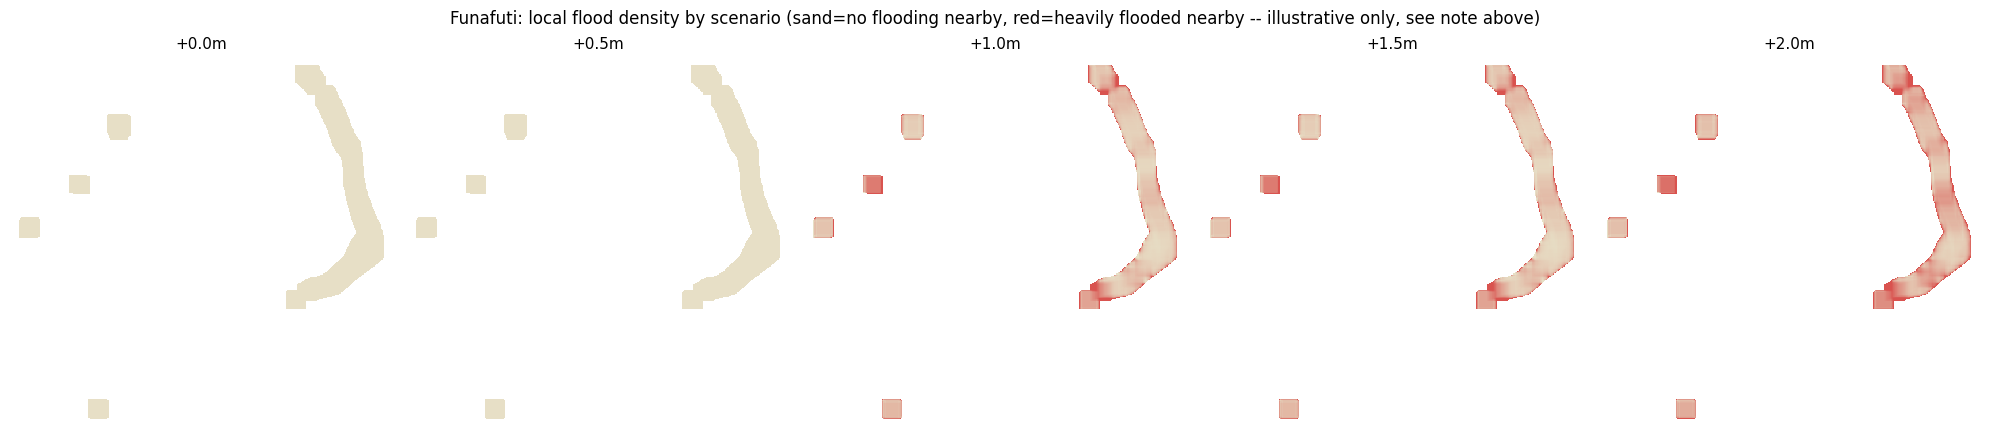

In [8]:
from scipy.ndimage import uniform_filter
import matplotlib.colors as mcolors

DISPLAY_RADIUS = 14  # cosmetic only -- does not affect analysis numbers
window_size = DISPLAY_RADIUS * 2 + 1
sand_to_red = mcolors.LinearSegmentedColormap.from_list("sand_to_red", ["#E7DFC6", "#D9534F"])

land_density = uniform_filter(baseline_land_mask.astype(float), size=window_size)
show_mask_full = land_density > 0.001  # where there's meaningful land nearby, at all

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(4 * len(SCENARIOS), 4.5))
for ax, scenario in zip(axes, SCENARIOS):
    mask = flood_masks[scenario["label"]]
    flood_density = uniform_filter(mask.astype(float), size=window_size)
    frac_flooded = np.divide(flood_density, land_density,
                              out=np.zeros_like(flood_density), where=land_density > 1e-6)

    display = np.where(show_mask_full, frac_flooded, np.nan)
    cropped = display[row_min:row_max, col_min:col_max]
    ax.imshow(cropped, cmap=sand_to_red, vmin=0, vmax=1, interpolation="nearest")
    ax.set_facecolor("white")
    ax.set_title(f"+{scenario['rise_m']}m", fontsize=11)
    ax.axis("off")
plt.suptitle("Funafuti: local flood density by scenario (sand=no flooding nearby, red=heavily "
             "flooded nearby -- illustrative only, see note above)")
plt.tight_layout()
plt.show()

## 8. Save results

Reported population counts are rounded to whole people. The native clipped
WorldPop total is retained separately from the population overlapping the
DEM-positive baseline.

In [9]:
output = {
    "meta": {
        "baseline_land_area_km2": round(float(baseline_land_area_km2), 3),
        "baseline_population": baseline_population_count,
        "native_clipped_worldpop_total": int(round(float(population_true_total))),
        "scenario_definition": (
            "Illustrative relative sea-level increments used as DEM elevation thresholds; "
            "not year-specific forecasts."
        ),
        "baseline_definition": (
            "Baseline land is valid DEM pixels with elevation > 0 m inside the Funafuti "
            "administrative clip. This is an analytical model baseline, not Funafuti's "
            "official land-area statistic."
        ),
        "population_definition": (
            "WorldPop modelled population is reprojected/resampled to the DEM grid using "
            "nearest-neighbour; NoData is excluded; the resampled total is rescaled to "
            "preserve the native clipped WorldPop total. Reported whole-person counts are "
            "rounded to the nearest integer."
        ),
        "model_limitation": (
            "Elevation-threshold screening model; no tides, waves, "
            "storm surge, groundwater flooding, erosion, drainage, coastal defences, "
            "hydrodynamic connectivity, or future shoreline geomorphology."
        ),
    },
    "scenarios": results,
}

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2)

print(f"Saved scenario statistics to {OUTPUT_JSON}")

Saved scenario statistics to ..\output\sea_level_scenarios.json


## 9. Build sequence

After this notebook, run:

1. `02_export_geojson.ipynb`
2. `04_sea_level_trend.ipynb`
3. `05_build_html.ipynb`

The generated `web/index.html` and `docs/index.html` should be rebuilt from
`web/index_template.html` rather than edited directly.